In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from pybaseball import lahman
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [26]:
mlb_stats2025 = pd.read_csv("data/mlb_stats2025.csv")
mlb_stats2025["Season"] = 2025
mlb_stats2024 = pd.read_csv("data/mlb_stats2024.csv")
mlb_stats2024["Season"] = 2024
mlb_stats2023 = pd.read_csv("data/mlb_stats2023.csv")
mlb_stats2023["Season"] = 2023
mlb_stats2022 = pd.read_csv("data/mlb_stats2022.csv")
mlb_stats2022["Season"] = 2022
mlb_stats2021 = pd.read_csv("data/mlb_stats2021.csv")
mlb_stats2021["Season"] = 2021
mlb_stats2020 = pd.read_csv("data/mlb_stats2020.csv")
mlb_stats2020["Season"] = 2020
mlb_stats2019 = pd.read_csv("data/mlb_stats2019.csv")
mlb_stats2019["Season"] = 2019
mlb_stats2018 = pd.read_csv("data/mlb_stats2018.csv")
mlb_stats2018["Season"] = 2018
mlb_stats2017 = pd.read_csv("data/mlb_stats2017.csv")
mlb_stats2017["Season"] = 2017
mlb_stats2016 = pd.read_csv("data/mlb_stats2016.csv")
mlb_stats2016["Season"] = 2016

mlb_stats1989 = pd.read_csv("data/mlb_stats1989.csv")
mlb_stats1989["Season"] = 1989
mlb_stats1988 = pd.read_csv("data/mlb_stats1988.csv")
mlb_stats1988["Season"] = 1988
mlb_stats1987 = pd.read_csv("data/mlb_stats1987.csv")
mlb_stats1987["Season"] = 1987
mlb_stats1986 = pd.read_csv("data/mlb_stats1986.csv")
mlb_stats1986["Season"] = 1986
mlb_stats1985 = pd.read_csv("data/mlb_stats1985.csv")
mlb_stats1985["Season"] = 1985
mlb_stats1984 = pd.read_csv("data/mlb_stats1984.csv")
mlb_stats1984["Season"] = 1984
mlb_stats1983 = pd.read_csv("data/mlb_stats1983.csv")
mlb_stats1983["Season"] = 1983
mlb_stats1982 = pd.read_csv("data/mlb_stats1982.csv")
mlb_stats1982["Season"] = 1982
mlb_stats1981 = pd.read_csv("data/mlb_stats1981.csv")
mlb_stats1981["Season"] = 1981
mlb_stats1980 = pd.read_csv("data/mlb_stats1980.csv")
mlb_stats1980["Season"] = 1980

mlb_stats = pd.concat([mlb_stats2025,mlb_stats2024,mlb_stats2023,mlb_stats2022,mlb_stats2021,mlb_stats2020,mlb_stats2019,mlb_stats2018,mlb_stats2017,mlb_stats2016
                        ,mlb_stats1989,mlb_stats1988,mlb_stats1987,mlb_stats1986,mlb_stats1985,mlb_stats1984,mlb_stats1983,mlb_stats1982,mlb_stats1981,mlb_stats1980])
mlb_stats['Player'] = mlb_stats['Player'].str.replace('*', '', regex=False)
mlb_stats['Player'] = mlb_stats['Player'].str.replace('#', '', regex=False)
mlb_stats

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Season
0,1,Francisco Lindor,31,NYM,NL,5.9,160,732,644,117,...,300,9,16,0,7,2,*6/DH,ASMVP-10,lindofr01,2025
1,2,Rafael Devers,28,2TM,2LG,4.1,163,729,607,99,...,291,16,6,0,4,10,*D3/5H,NaN,deverra01,2025
2,3,Shohei Ohtani,30,LAD,NL,6.6,158,727,611,146,...,380,9,3,0,2,20,*D1,ASMVP-1SS,ohtansh01,2025
3,4,Matt Olson,31,ATL,NL,6.0,162,724,624,98,...,302,14,4,0,5,2,*3,ASMVP-18GG,olsonma02,2025
4,5,Kyle Schwarber,32,PHI,NL,4.7,162,724,604,111,...,340,4,11,0,1,6,*D/7,ASMVP-2,schwaky01,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,756,Steve Stone,32,BAL,AL,-0.1,12,0,0,0,...,0,0,0,0,0,0,1D,ASCYA-1MVP-9,stonest01,1980
756,757,Dave Tobik,27,DET,AL,0.0,1,0,0,0,...,0,0,0,0,0,0,1,NaN,tobikda01,1980
757,758,Mike Torrez,33,BOS,AL,0.0,1,0,0,0,...,0,0,0,0,0,0,1,NaN,torremi01,1980
758,759,Gary Weiss,24,LAD,NL,0.0,8,0,0,2,...,0,0,0,0,0,0,/H,NaN,weissga01,1980


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Stolen Bases against Runs from Qualified Hitters from 2016-2025 with a SB/G of at least 0.1')

Text(0.5, 0, 'SB/G')

Text(0, 0.5, 'R')

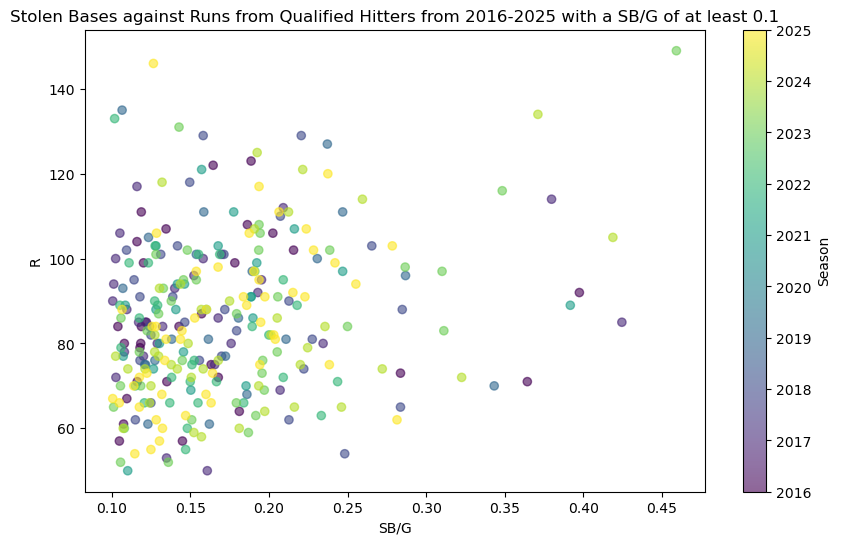

In [32]:
sb_pg = mlb_stats.groupby(['Season', 'Player'])[['SB', 'R', 'G','PA']].sum().reset_index()
sb_pg['SB/G'] = sb_pg['SB'] / sb_pg['G']
filtered_players = sb_pg[(sb_pg['PA'] >= 502) & (sb_pg['SB/G'] > 0.1)]
sb_pg_filtered = filtered_players[(filtered_players['Season'] >= 2016) & (filtered_players['Season'] < 2026)]
plt.figure(figsize=(10, 6))
scatter = plt.scatter(sb_pg_filtered['SB/G'], sb_pg_filtered['R'], 
                      c=sb_pg_filtered['Season'], alpha=0.6)
plt.colorbar(scatter, label='Season')
plt.title("Stolen Bases against Runs from Qualified Hitters from 2016-2025 with a SB/G of at least 0.1" )
plt.xlabel("SB/G")
plt.ylabel("R")
plt.savefig("Visual2.png")